In [75]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline


### Q1: Robust Data Loading and Missing Value Handling

a) load_and_inspect : Creating a load_and_inspect function where I load the csv check the shape, datatype, missing value % and satistical summary of the dataset.

b) handle_missing: Creating handle_missing function to handle the missing values

c) unit tests: here we verify handling_missing func on synthetic data we generate. We are testing on three scenarios 1) col with all null values and 2) col with no missing values should remain untouched 3)ouput col shouldn't have any missing numeric values

In [25]:
def load_and_inspect(filepath):
    df=pd.read_csv(filepath) #reads the csv file
    print("First 5 rows of the dataset:")
    print(df.head())
    print("\nDataset shape (rows, columns):")
    print(df.shape)
    print("\nColumn data types:")
    print(df.dtypes)
    print("\nMissing values % in each column:")
    print(pd.DataFrame({'count': df.isnull().sum(), 'percentage': df.isnull().sum() / len(df) * 100}))
    print("\nDataset summary:")
    print(df.describe())
    return df


df=load_and_inspect('dataset/data.csv')

First 5 rows of the dataset:
   Country   Age   Salary Purchased
0   France  44.0  72000.0        No
1    Spain  27.0  48000.0       Yes
2  Germany  30.0  54000.0        No
3    Spain  38.0  61000.0        No
4  Germany  40.0      NaN       Yes

Dataset shape (rows, columns):
(10, 4)

Column data types:
Country       object
Age          float64
Salary       float64
Purchased     object
dtype: object

Missing values % in each column:
           count  percentage
Country        0         0.0
Age            1        10.0
Salary         1        10.0
Purchased      0         0.0

Dataset summary:
             Age        Salary
count   9.000000      9.000000
mean   38.777778  63777.777778
std     7.693793  12265.579662
min    27.000000  48000.000000
25%    35.000000  54000.000000
50%    38.000000  61000.000000
75%    44.000000  72000.000000
max    50.000000  83000.000000


In [43]:
def handling_missing(df, strategy='mean'): #only handling numerical columns
    num_cols = df.select_dtypes(include=[np.number]).columns
    print(num_cols)
    num_cols =[col for col in num_cols if df[col].notna().any()] #removing columns with all missing values
    imputer = SimpleImputer(strategy=strategy)
    print(imputer.fit_transform(df[num_cols]).shape)
    df[num_cols] = imputer.fit_transform(df[num_cols])        
    return df

null_imputed_df=handling_missing(df,strategy='mean')
print("\nDataset after handling missing values:")
print(null_imputed_df.head())

Index(['Age', 'Salary'], dtype='object')
(10, 2)

Dataset after handling missing values:
   Country   Age        Salary Purchased
0   France  44.0  72000.000000        No
1    Spain  27.0  48000.000000       Yes
2  Germany  30.0  54000.000000        No
3    Spain  38.0  61000.000000        No
4  Germany  40.0  63777.777778       Yes


In [ ]:
import unittest

class TestHandleMissing(unittest.TestCase):
    
    def setUp(self):
        # synthetic test data created fresh before each test
        self.test_df = pd.DataFrame({
            'A': [np.nan, np.nan, np.nan],  # col with all missing values
            'B': [1, 2, 3],                  # col with no missing values
            'C': [4, np.nan, 6]              # col with some missing values
        })
    
    def test_all_null_col_remains_null(self):
        result = handling_missing(self.test_df.copy(), strategy='mean')
        self.assertTrue(result['A'].isnull().all(), "Col A should remain NaN — all-null cols are skipped")
    
    def test_no_missing_col_unchanged(self):
        original_B = self.test_df['B'].copy()
        result = handling_missing(self.test_df.copy(), strategy='mean')
        self.assertTrue(result['B'].equals(original_B), "Col B should not be modified")
    
    def test_partial_missing_col_imputed(self):
        result = handling_missing(self.test_df.copy(), strategy='mean')
        self.assertEqual(result['C'].isnull().sum(), 0, "Col C should have no missing values after imputation")

# run tests
suite = unittest.TestLoader().loadTestsFromTestCase(TestHandleMissing)
runner = unittest.TextTestRunner(verbosity=2)
runner.run(suite)

### Q2: Encoding Pipeline with Validation

a) encode_features: creating encode func to perform one-hot encode (each val gets its own binary cols) and label-encode (for target col) 

b) identify encoded features cols names

c) check if decoding predictions gets back the original value


In [49]:
def encode_features(df, categorical_cols, target_col):
    X= df.drop(columns=[target_col])
    y = df[target_col]
    #passing categorical cols directly where sklearn handles finding the index internally
    ct = ColumnTransformer([('encoder', OneHotEncoder(), categorical_cols)], remainder='passthrough') #one hot encoding the categorical column
    X = np.array(ct.fit_transform(X))
    le = LabelEncoder()
    y = le.fit_transform(y) #label encoding the target column
    return X, y, ct, le

X, y, ct, le = encode_features(df, ['Country'], 'Purchased')
print("\nOne-Hot Encoded features (X):")
print(X)
print("\nLabel Encoded target (y):")
print(y)


One-Hot Encoded features (X):
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 4.40000000e+01
  7.20000000e+04]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 2.70000000e+01
  4.80000000e+04]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 3.00000000e+01
  5.40000000e+04]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 3.80000000e+01
  6.10000000e+04]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 4.00000000e+01
  6.37777778e+04]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 3.50000000e+01
  5.80000000e+04]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 3.87777778e+01
  5.20000000e+04]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 4.80000000e+01
  7.90000000e+04]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 5.00000000e+01
  8.30000000e+04]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 3.70000000e+01
  6.70000000e+04]]

Label Encoded target (y):
[0 1 0 0 1 1 0 1 0 1]


In [ ]:
# Check the new encoded feature names
col_names = ct.get_feature_names_out()
print("\nOne-Hot Encoded feature names:")
print(pd.DataFrame(X, columns=col_names))


One-Hot Encoded feature names:
   encoder__Country_France  encoder__Country_Germany  encoder__Country_Spain  \
0                      1.0                       0.0                     0.0   
1                      0.0                       0.0                     1.0   
2                      0.0                       1.0                     0.0   
3                      0.0                       0.0                     1.0   
4                      0.0                       1.0                     0.0   
5                      1.0                       0.0                     0.0   
6                      0.0                       0.0                     1.0   
7                      1.0                       0.0                     0.0   
8                      0.0                       1.0                     0.0   
9                      1.0                       0.0                     0.0   

   remainder__Age  remainder__Salary  
0       44.000000       72000.000000  
1       2

In [ ]:
#decoding the encoded target variable to check if it matches the original value.
def decode_predictions(y_encoded, le):
    return le.inverse_transform(y_encoded)
decoded = decode_predictions(y, le)
print(decoded)
assert list(decoded) == list(df['Purchased']), "Decoded values don't match originals"

['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


### Q3. Train & Test Split Analysis and Scaling
a)creating train test splits with different test sizes with randomised data split and we store the train and test class

b)then we interpret the results in a plot to understand class distribution to find which test size is most reliable.

c)comparing scalers to see which respresentation fits best for our data.

In [58]:
def split_experiment(X, y, test_sizes,n_repeats=10):
    result_rows = []
    for test_size in test_sizes:
        for random_state in range(n_repeats):
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
            result_rows.append({
                    'test_size': test_size,
                    'random_state': random_state,
                    'train_class_0': np.bincount(y_train, minlength=2)[0],
                    'train_class_1': np.bincount(y_train, minlength=2)[1],
                    'test_class_0': np.bincount(y_test, minlength=2)[0],
                    'test_class_1': np.bincount(y_test, minlength=2)[1]})
    return pd.DataFrame(result_rows)

test_sizes = [0.2, 0.3, 0.4]
experiment_results = split_experiment(X, y, test_sizes)
print("\nExperiment results:")
print(experiment_results)
    


Experiment results:
    test_size  random_state  train_class_0  train_class_1  test_class_0  \
0         0.2             0              3              5             2   
1         0.2             1              4              4             1   
2         0.2             2              5              3             0   
3         0.2             3              5              3             0   
4         0.2             4              3              5             2   
5         0.2             5              5              3             0   
6         0.2             6              4              4             1   
7         0.2             7              4              4             1   
8         0.2             8              3              5             2   
9         0.2             9              4              4             1   
10        0.3             0              3              4             2   
11        0.3             1              3              4             2   
12  

C:\Users\Uma\AppData\Local\Temp\ipykernel_9368\169320577.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_test = experiment_results.groupby('test_size').apply(lambda x: (x['test_class_0'] + x['test_class_1']).mean())


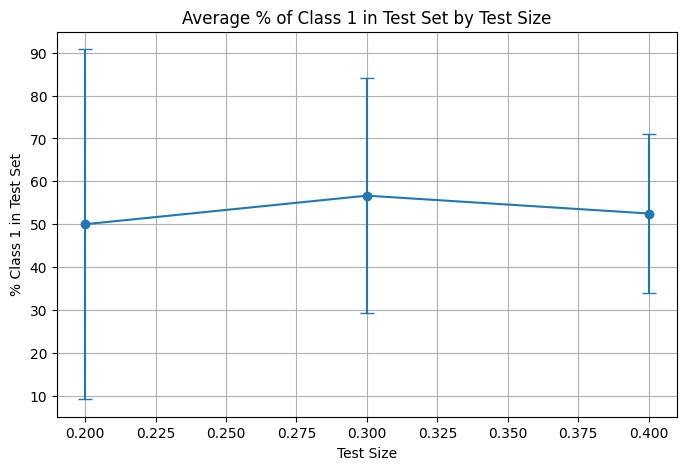

In [60]:
import matplotlib.pyplot as plt

grouped = experiment_results.groupby('test_size')['test_class_1'].agg(['mean', 'std'])
total_test = experiment_results.groupby('test_size').apply(lambda x: (x['test_class_0'] + x['test_class_1']).mean())
avg_pct = grouped['mean'] / total_test * 100
std_pct = grouped['std'] / total_test * 100

plt.figure(figsize=(8, 5))
plt.errorbar(avg_pct.index, avg_pct.values, yerr=std_pct.values, marker='o', capsize=5)
plt.title('Average % of Class 1 in Test Set by Test Size')
plt.xlabel('Test Size')
plt.ylabel('% Class 1 in Test Set')
plt.grid(True)
plt.show()

#insight: As the test size increases the error bars decrease which indicates that the variance in the percentage of class 1 in the test set reduces with larger test sizes
#here test size 0.4 preserves the class distb better, however we only have 10 rows which is too few for any split to be realiable.

In [67]:
#creating a single train-test split for further processing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
def compare_scalers(X_train, X_test, scaler_classes):
    results = {}
    for scaler_class in scaler_classes:
        scaler = scaler_class()
        name = scaler_class.__name__
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        results[name] = {
            'train_mean': np.mean(X_train_scaled, axis=0),
            'train_std': np.std(X_train_scaled, axis=0),
            'test_mean': np.mean(X_test_scaled, axis=0),
            'test_std': np.std(X_test_scaled, axis=0),
        }
        print(f"\n{name}:")
        print(f"  Train — Mean: {np.mean(X_train_scaled, axis=0).round(3)}, Std: {np.std(X_train_scaled, axis=0).round(3)}")
        print(f"  Test  — Mean: {np.mean(X_test_scaled, axis=0).round(3)}, Std: {np.std(X_test_scaled, axis=0).round(3)}")
    
    print("\n--- Scaler Comparison Summary ---")
    print("StandardScaler : Mean≈0, Std=1 on train. Best when data is approx. normally distributed. Sensitive to outliers.")
    print("MinMaxScaler   : Squeezes all values to [0,1]. Good for algorithms needing bounded input. Very sensitive to outliers.")
    print("RobustScaler   : Uses median and IQR — not affected by outliers. Best choice when data has extreme values.")
    print("\nRecommendation: For this dataset with potential salary outliers, RobustScaler is safest.")
    
    return results

results = compare_scalers(X_train, X_test, [StandardScaler, MinMaxScaler, RobustScaler])

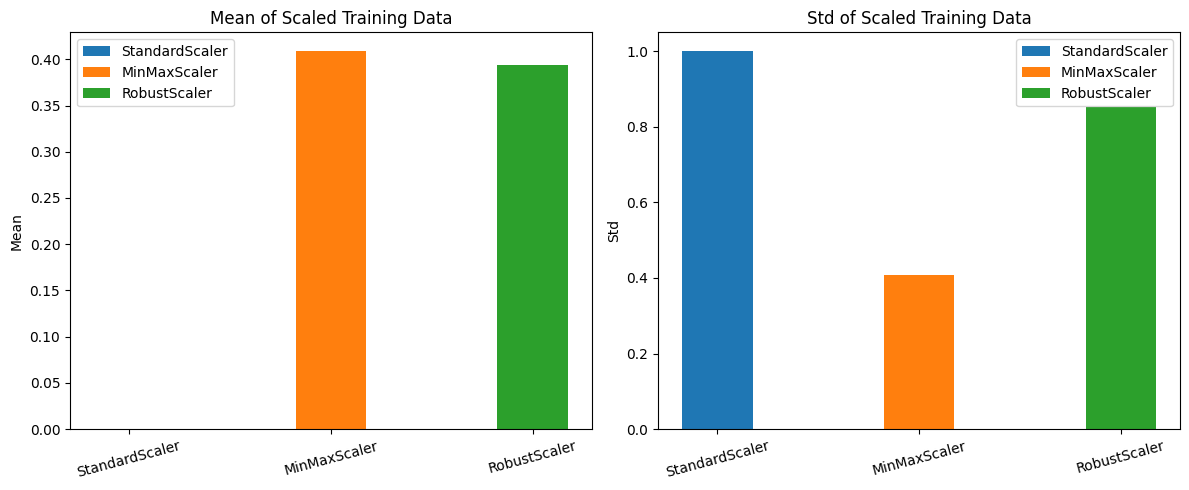

In [69]:
import matplotlib.pyplot as plt
import numpy as np

scaler_names = list(results.keys())
x = np.arange(len(scaler_names))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i, name in enumerate(scaler_names):
    means = results[name]['train_mean']
    stds = results[name]['train_std']
    ax1.bar(x[i], np.mean(means), width, label=name)
    ax2.bar(x[i], np.mean(stds), width, label=name)

ax1.set_title('Mean of Scaled Training Data')
ax1.set_xticks(x); ax1.set_xticklabels(scaler_names, rotation=15)
ax1.set_ylabel('Mean'); ax1.legend()

ax2.set_title('Std of Scaled Training Data')
ax2.set_xticks(x); ax2.set_xticklabels(scaler_names, rotation=15)
ax2.set_ylabel('Std'); ax2.legend()

plt.tight_layout()
plt.show()


### Q4: End to End Reusable Pipeline Creation

In [81]:
target_col ='Purchased'
numerical_cols = [col for col in df.columns if df[col].dtype in [np.int64, np.float64]]
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != target_col]
print(f"Numerical columns:{numerical_cols}\nCategorical columns: {categorical_cols}")

Numerical columns:['Age', 'Salary']
Categorical columns: ['Country']


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# handle_unknown='ignore' outputs all zeros for unseen categories instead of raising an error
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [86]:
X = df.drop(columns=['Purchased'])
y = LabelEncoder().fit_transform(df['Purchased'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
print(f"\nTransformed training features (X_train): {X_train_transformed.shape[0]} rows, {X_train_transformed.shape[1]} columns")
print(f"Transformed test features (X_test): {X_test_transformed.shape[0]} rows, {X_test_transformed.shape[1]} columns")


Transformed training features (X_train): 6 rows, 5 columns
Transformed test features (X_test): 4 rows, 5 columns


In [87]:
col_names = preprocessor.get_feature_names_out()
print(pd.DataFrame(X_train_transformed, columns=col_names))
print(pd.DataFrame(X_test_transformed, columns=col_names))

   num__Age  num__Salary  cat__Country_France  cat__Country_Germany  \
0  0.462364     0.421194                  1.0                   0.0   
1 -0.294232    -0.475542                  0.0                   0.0   
2 -1.681325    -1.535320                  0.0                   0.0   
3  0.966762     0.991844                  1.0                   0.0   
4  1.218961     1.317930                  0.0                   1.0   
5 -0.672530    -0.720106                  1.0                   0.0   

   cat__Country_Spain  
0                 0.0  
1                 1.0  
2                 1.0  
3                 0.0  
4                 0.0  
5                 0.0  
   num__Age  num__Salary  cat__Country_France  cat__Country_Germany  \
0 -1.303027    -1.046192                  0.0                   1.0   
1 -0.420331     0.013587                  1.0                   0.0   
2 -0.196155    -1.209235                  0.0                   0.0   
3 -0.042033    -0.249093                  0.0     

In [ ]:
def test_pipeline_on_new_data(pipeline, new_data, col_names):
    print("Testing pipeline on new data:\n")
    for i, row in new_data.iterrows():
        try:
            result = pipeline.transform(pd.DataFrame([row]))
            print(f"Row {i} — transformed successfully:")
            print(pd.DataFrame(result, columns=col_names))
        except Exception as e:
            print(f"Row {i} — failed: {e}")

In [ ]:
new_data = pd.DataFrame({
    'Country': ['Italy', 'Germany', 'France'],
    'Age':     [25.0, np.nan, 55.0],
    'Salary':  [60000.0, 70000.0, 80000.0]
})

col_names = preprocessor.get_feature_names_out()

print("New data:")
print(new_data)
print()
test_pipeline_on_new_data(preprocessor, new_data, col_names)

# Italy is an unknown category not seen during training.
# With handle_unknown='ignore', OneHotEncoder outputs all zeros for its country columns
# instead of raising an error — the pipeline handles it gracefully.

In [92]:
import joblib
def save_and_load_pipeline(pipeline, filepath):
    joblib.dump(pipeline, filepath)
    loaded_pipeline = joblib.load(filepath)
    
    original_output = pipeline.transform(X_test)
    loaded_output = loaded_pipeline.transform(X_test)
    
    assert np.allclose(original_output, loaded_output), "Pipeline outputs don't match!"
    print("Pipeline saved, loaded successfully and outputs match")
    return loaded_pipeline

save_and_load_pipeline(preprocessor, 'pipeline.pkl')


Pipeline saved, loaded successfully and outputs match


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `